In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Setting paths

DATA_PATH = Path("../data/processed/london_air_quality_features_2021_2024.csv")
FIGURES_DIR = Path("../outputs/figures")
RESULTS_PATH = Path("../outputs/baseline_model_results.csv")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

In [3]:
# Checking input file

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Engineered dataset not found: {DATA_PATH.resolve()}"
    )

print("Input:", DATA_PATH)

Input: ..\data\processed\london_air_quality_features_2021_2024.csv


In [4]:
# Loading data

df = pd.read_csv(DATA_PATH)
df["Datetime"] = pd.to_datetime(df["Datetime"])

print("Shape:", df.shape)
print("Date range:", df["Datetime"].min(), "→", df["Datetime"].max())
print("Stations:", df["Station"].nunique())

Shape: (147228, 33)
Date range: 2021-01-01 01:00:00 → 2024-12-31 22:00:00
Stations: 5


In [5]:
# Checking required columns

target = "PM2.5_target"

features = [
    "NO2", "PM10", "PM2.5", "O3",
    "Temperature", "Dewpoint", "Humidity",
    "WindSpeed", "WindDirection", "Pressure", "Visibility",
    "Year", "Month", "Day", "Hour", "DayOfWeek",
    "DayOfYear", "WeekOfYear", "IsWeekend",
    "PM2.5_lag_1h", "PM2.5_lag_3h", "PM2.5_lag_6h",
    "PM2.5_lag_24h", "PM2.5_rolling_3h",
    "PM2.5_rolling_6h", "PM2.5_rolling_24h",
    "Temperature_Humidity", "WindSpeed_Squared",
    "Pressure_Change"
]

required_columns = ["Datetime", "Station", target] + features

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Required columns:", len(required_columns))
print("Missing required columns:", len(missing_columns))

Required columns: 32
Missing required columns: 0


In [6]:
# Checking duplicates

duplicates = df.duplicated(
    subset=["Station", "Datetime"]
).sum()

print("Duplicate Station-Datetime rows:", duplicates)

if duplicates != 0:
    raise ValueError("Duplicate Station-Datetime rows detected.")

Duplicate Station-Datetime rows: 0


In [7]:
# Creating train/test split

train_df = df[df["Datetime"].dt.year <= 2023].copy()
test_df = df[df["Datetime"].dt.year == 2024].copy()

print("Training shape:", train_df.shape)
print(
    "Training period:",
    train_df["Datetime"].min(),
    "→",
    train_df["Datetime"].max()
)

print()
print("Testing shape:", test_df.shape)
print(
    "Testing period:",
    test_df["Datetime"].min(),
    "→",
    test_df["Datetime"].max()
)

Training shape: (108102, 33)
Training period: 2021-01-01 01:00:00 → 2023-12-31 22:00:00

Testing shape: (39126, 33)
Testing period: 2024-01-01 01:00:00 → 2024-12-31 22:00:00


In [8]:
# Checking train/test separation

if train_df["Datetime"].max() >= test_df["Datetime"].min():
    raise ValueError("Training and testing periods overlap.")

print("Train/test overlap: 0")

Train/test overlap: 0


In [9]:
# Creating X and y

X_train = train_df[features].copy()
X_test = test_df[features].copy()

y_train = train_df[target].copy()
y_test = test_df[target].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (108102, 29)
X_test: (39126, 29)
y_train: (108102,)
y_test: (39126,)


In [10]:
# Checking target values

print("Training target:")
print(y_train.describe())

print()
print("Testing target:")
print(y_test.describe())

if y_train.isna().any() or y_test.isna().any():
    raise ValueError("Missing target values detected.")

Training target:
count    108102.000000
mean          8.594547
std           7.102222
min           0.000000
25%           4.245000
50%           6.604000
75%          10.472000
max          96.793000
Name: PM2.5_target, dtype: float64

Testing target:
count    39126.000000
mean         7.595094
std          5.991856
min          0.000000
25%          3.797000
50%          5.896000
75%          9.360750
max        121.321000
Name: PM2.5_target, dtype: float64


In [11]:
# Checking feature missing values

print(
    "Training missing values:",
    X_train.isna().sum().sum()
)

print(
    "Testing missing values:",
    X_test.isna().sum().sum()
)

Training missing values: 77227
Testing missing values: 21325


In [12]:
# Imputing missing features

imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

print(
    "Training missing values after imputation:",
    X_train_imputed.isna().sum().sum()
)

print(
    "Testing missing values after imputation:",
    X_test_imputed.isna().sum().sum()
)

Training missing values after imputation: 0
Testing missing values after imputation: 0


In [13]:
# Scaling features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (108102, 29)
X_test_scaled: (39126, 29)


In [14]:
# Training Linear Regression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [15]:
# Training Random Forest

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_imputed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [16]:
# Generating predictions

linear_predictions = linear_model.predict(
    X_test_scaled
)

rf_predictions = rf_model.predict(
    X_test_imputed
)

print(
    "Linear Regression predictions:",
    linear_predictions.shape
)

print(
    "Random Forest predictions:",
    rf_predictions.shape
)

Linear Regression predictions: (39126,)
Random Forest predictions: (39126,)


In [17]:
# Evaluating models

def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = pd.DataFrame([
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
])

print(results.round(3).to_string(index=False))

            Model   MAE  RMSE    R2
Linear Regression 1.333 2.435 0.835
    Random Forest 1.240 2.237 0.861


In [18]:
# Selecting best baseline

best_model = results.sort_values(
    "RMSE"
).iloc[0]

print("Best baseline:", best_model["Model"])
print("MAE:", round(best_model["MAE"], 3))
print("RMSE:", round(best_model["RMSE"], 3))
print("R²:", round(best_model["R2"], 3))

Best baseline: Random Forest
MAE: 1.24
RMSE: 2.237
R²: 0.861


In [19]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(feature_importance.head(15))

              Feature  Importance
0               PM2.5    0.907481
1        PM2.5_lag_1h    0.008138
2                PM10    0.007340
3    PM2.5_rolling_3h    0.005802
4          Visibility    0.005560
5                 NO2    0.004730
6   PM2.5_rolling_24h    0.004654
7            Humidity    0.004584
8            Pressure    0.004547
9                Hour    0.004409
10      PM2.5_lag_24h    0.003903
11   PM2.5_rolling_6h    0.003686
12       PM2.5_lag_3h    0.003426
13       PM2.5_lag_6h    0.003276
14                 O3    0.003216


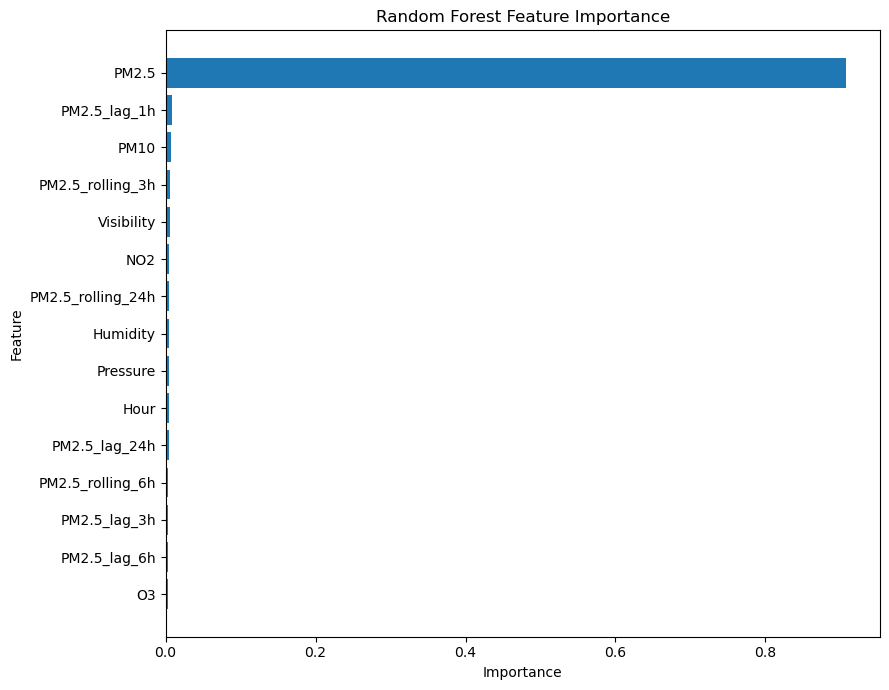

Saved: ..\outputs\figures\random_forest_feature_importance.png


In [20]:
# Saving feature importance figure

top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

importance_path = FIGURES_DIR / "random_forest_feature_importance.png"
plt.savefig(importance_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", importance_path)

In [21]:
# Creating prediction comparison

prediction_df = pd.DataFrame({
    "Datetime": test_df["Datetime"].values,
    "Station": test_df["Station"].values,
    "Actual": y_test.values,
    "Linear_Regression": linear_predictions,
    "Random_Forest": rf_predictions
})

prediction_df.head(10)

,Datetime,Station,Actual,Linear_Regression,Random_Forest
0,2024-01-02 15:00:00,London Bloomsbury,2.311,6.540774,5.316751
1,2024-01-02 16:00:00,London Bloomsbury,1.439,4.070003,3.491156
2,2024-01-02 17:00:00,London Bloomsbury,2.170,2.712751,2.459304
3,2024-01-02 18:00:00,London Bloomsbury,3.349,2.596539,3.101648
4,2024-01-02 19:00:00,London Bloomsbury,4.835,3.763072,4.719785
5,2024-01-02 20:00:00,London Bloomsbury,6.604,5.241387,5.506605
6,2024-01-02 21:00:00,London Bloomsbury,7.005,6.723816,7.220668
7,2024-01-02 22:00:00,London Bloomsbury,7.146,7.203164,7.124277
8,2024-01-03 01:00:00,London Bloomsbury,7.594,5.579946,6.125050
9,2024-01-03 02:00:00,London Bloomsbury,8.561,7.173621,7.800696


In [22]:
# Checking prediction alignment

if len(prediction_df) != len(test_df):
    raise ValueError("Prediction length does not match testing data.")

print("Prediction rows:", len(prediction_df))
print("Testing rows:", len(test_df))
print("Alignment check: passed")

Prediction rows: 39126
Testing rows: 39126
Alignment check: passed


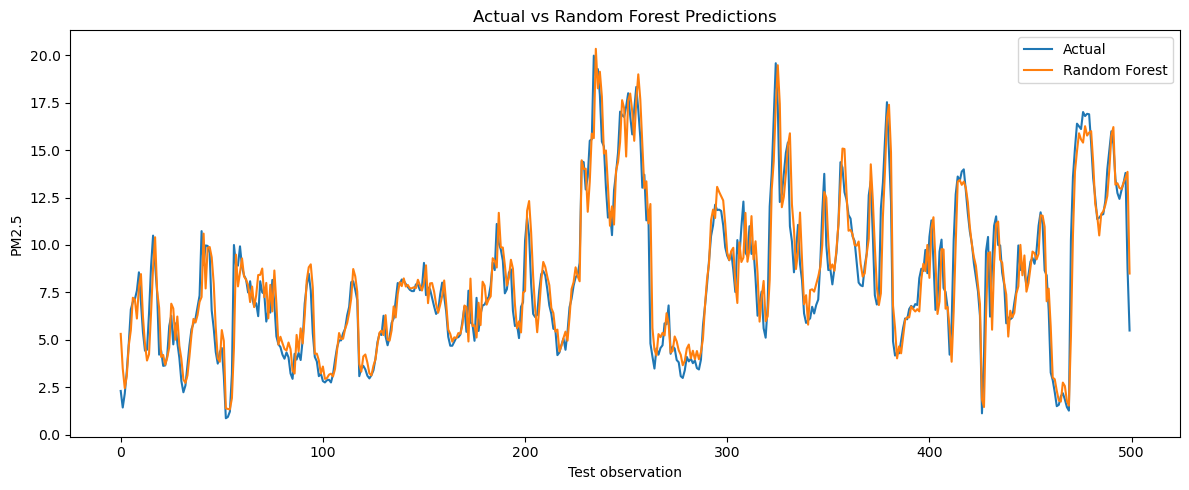

Saved: ..\outputs\figures\random_forest_actual_vs_predicted.png


In [23]:
# Plotting Random Forest predictions

plt.figure(figsize=(12, 5))

plot_data = prediction_df.iloc[:500]

plt.plot(
    plot_data["Actual"].to_numpy(),
    label="Actual"
)

plt.plot(
    plot_data["Random_Forest"].to_numpy(),
    label="Random Forest"
)

plt.xlabel("Test observation")
plt.ylabel("PM2.5")
plt.title("Actual vs Random Forest Predictions")
plt.legend()
plt.tight_layout()

prediction_path = FIGURES_DIR / "random_forest_actual_vs_predicted.png"
plt.savefig(prediction_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", prediction_path)

In [24]:
# Calculating Random Forest residuals

prediction_df["RF_Residual"] = (
    prediction_df["Actual"] -
    prediction_df["Random_Forest"]
)

print(prediction_df["RF_Residual"].describe())

count    39126.000000
mean        -0.019949
std          2.236723
min        -66.614806
25%         -0.730167
50%         -0.101303
75%          0.550636
max         78.800576
Name: RF_Residual, dtype: float64


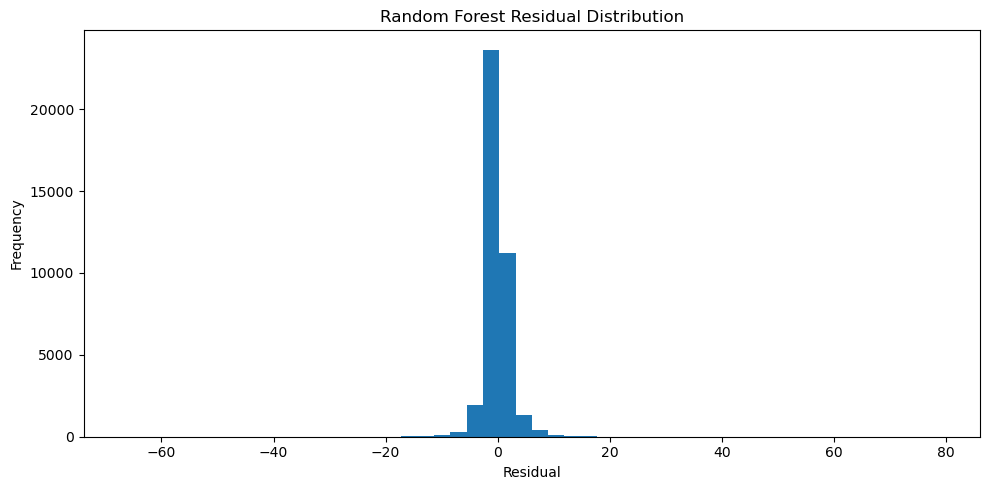

Saved: ..\outputs\figures\random_forest_residual_distribution.png


In [25]:
# Plotting Random Forest residuals

plt.figure(figsize=(10, 5))

plt.hist(
    prediction_df["RF_Residual"],
    bins=50
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Random Forest Residual Distribution")
plt.tight_layout()

residual_path = FIGURES_DIR / "random_forest_residual_distribution.png"
plt.savefig(residual_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", residual_path)

In [26]:
# Saving model results

results.to_csv(
    RESULTS_PATH,
    index=False
)

print("Saved:", RESULTS_PATH)

Saved: ..\outputs\baseline_model_results.csv


In [27]:
# Final quality control

print("=" * 60)
print("FINAL BASELINE MODEL CHECK")
print("=" * 60)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Features:", len(features))
print("Training missing after imputation:", X_train_imputed.isna().sum().sum())
print("Testing missing after imputation:", X_test_imputed.isna().sum().sum())
print("Prediction rows:", len(prediction_df))
print()
print(results.round(3).to_string(index=False))
print()
print("Figures directory:", FIGURES_DIR)
print("Results file:", RESULTS_PATH)

FINAL BASELINE MODEL CHECK
Training rows: 108102
Testing rows: 39126
Features: 29
Training missing after imputation: 0
Testing missing after imputation: 0
Prediction rows: 39126

            Model   MAE  RMSE    R2
Linear Regression 1.333 2.435 0.835
    Random Forest 1.240 2.237 0.861

Figures directory: ..\outputs\figures
Results file: ..\outputs\baseline_model_results.csv
